# ALGORITMOS DE REGRESIÓN

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import yfinance as yf


In [48]:
# Usaremos yfinance para obtener los datos directamente desde Yahoo Finance:
# Descargar precios del Bitcoin (últimos 2 años)
btc = yf.download("BTC-USD", start="2023-01-01", end="2025-10-01")
# Revisar datos
print(btc.head())

C:\Users\mateo\AppData\Local\Temp\ipykernel_24136\3744303263.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2023-01-01", end="2025-10-01")
[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2023-01-01  16625.080078  16630.439453  16521.234375  16547.914062   
2023-01-02  16688.470703  16759.343750  16572.228516  16625.509766   
2023-01-03  16679.857422  16760.447266  16622.371094  16688.847656   
2023-01-04  16863.238281  16964.585938  16667.763672  16680.205078   
2023-01-05  16836.736328  16884.021484  16790.283203  16863.472656   

Price            Volume  
Ticker          BTC-USD  
Date                     
2023-01-01   9244361700  
2023-01-02  12097775227  
2023-01-03  13903079207  
2023-01-04  18421743322  
2023-01-05  13692758566  


In [49]:
# Crear columna de precio anterior
btc["Close_prev"] = btc["Close"].shift(1)
# Eliminar valores nulos
btc = btc.dropna()
# Variables independientes (X) y dependiente (Y)
X = btc[["Close_prev", "Volume"]]
y = btc["Close"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [51]:
# Crear modelo
modelo = LinearRegression()
# Entrenar modelo
modelo.fit(X_train, y_train)
# Mostrar coeficientes
print("Intercepto (a):", modelo.intercept_)
print("Coeficientes (b):", modelo.coef_)

Intercepto (a): [178.47959778]
Coeficientes (b): [[9.92479539e-01 9.75822594e-09]]


In [52]:
# Predicciones
y_pred = modelo.predict(X_test)
# Métricas de evaluación
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Coeficiente de determinación (R²): {r2:.3f}")
print(f"Error medio absoluto (MAE): ${mae:.2f}")

Coeficiente de determinación (R²): 0.975
Error medio absoluto (MAE): $1391.49


In [53]:
ultimo = btc.iloc[-1]
X_nuevo = np.array([ultimo[["Close", "Volume"]]]).reshape(1, -1)
prediccion = modelo.predict(X_nuevo)
print(f"Precio estimado de Bitcoin para el siguiente día: ${float(prediccion[0]):.2f}")


Precio estimado de Bitcoin para el siguiente día: $113952.41


C:\Users\mateo\AppData\Local\Temp\ipykernel_24136\2011529272.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Precio estimado de Bitcoin para el siguiente día: ${float(prediccion[0]):.2f}")


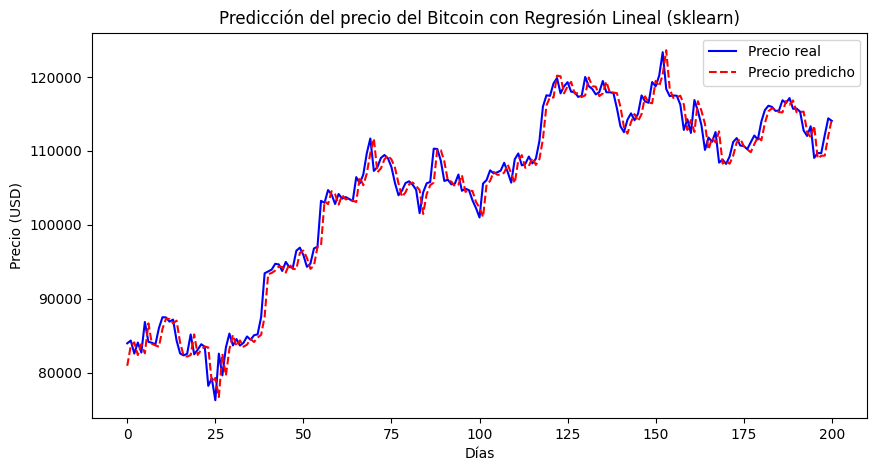

In [54]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Precio real", color="blue")
plt.plot(y_pred, label="Precio predicho", color="red", linestyle="--")
plt.title("Predicción del precio del Bitcoin con Regresión Lineal (sklearn)")
plt.xlabel("Días")
plt.ylabel("Precio (USD)")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import yfinance as yf

tsla = yf.download("TSLA", start="2023-01-01", end="2025-10-01")

tsla["Rendimiento"] = np.log(tsla["Close"] / tsla["Close"].shift(1))

tsla["Rend_prev"] = tsla["Rendimiento"].shift(1)

tsla = tsla.dropna()

X = tsla[["Rend_prev"]]
y = tsla["Rendimiento"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Intercepto:", modelo.intercept_)
print("Pendiente:", modelo.coef_[0])

y_pred = modelo.predict(X_test)

ultimo = btc.iloc[-1]
X_nuevo = np.array([ultimo["Rendimiento"]]).reshape(1, -1)
prediccion_siguiente = modelo.predict(X_nuevo)

rend_estimada = float(prediccion_siguiente[0])
precio_actual = float(ultimo["Close"])
precio_estimado = precio_actual * np.exp(rend_estimada)

print(f"Rendimiento estimado: {rend_estimada*100:.3f}%")
print(f"Precio estimado para el siguiente día: ${precio_estimado:.2f}")

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Rendimiento real", color="blue")
plt.plot(y_pred, label="Rendimiento predicho", color="red", linestyle="--")
plt.title("Predicción de rendimientos diarios de TSLA con Regresión Lineal")
plt.xlabel("Días")
plt.ylabel("Rendimiento logarítmico")
plt.legend()
plt.show()



C:\Users\mateo\AppData\Local\Temp\ipykernel_24136\1362396219.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsla = yf.download("TSLA", start="2023-01-01", end="2025-10-01")
[*********************100%***********************]  1 of 1 completed


ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.